In [1]:
!pip install torch torchvision matplotlib

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [2]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))

        # gate scores (same shape as weights)
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)
        pruned_weights = self.weight * gates
        return torch.matmul(x, pruned_weights.t()) + self.bias

In [3]:
class PrunableNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = PrunableLinear(32*32*3, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [4]:
transform = transforms.Compose([
    transforms.ToTensor()
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64)

100%|██████████| 170M/170M [00:03<00:00, 49.3MB/s]


In [5]:
def sparsity_loss(model):
    loss = 0
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            loss += torch.sum(gates)
    return loss

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_model(lambda_val, epochs=5):
    model = PrunableNet().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss_cls = criterion(outputs, labels)
            loss_sparse = sparsity_loss(model)

            loss = loss_cls + lambda_val * loss_sparse
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

    return model

In [7]:
def evaluate(model):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

In [8]:
def calculate_sparsity(model, threshold=1e-2):
    total = 0
    zero = 0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            total += gates.numel()
            zero += torch.sum(gates < threshold).item()

    return 100 * zero / total

In [10]:
lambdas = [0.0001, 0.01, 0.01]
results = []

for lam in lambdas:
    print(f"\nTraining with lambda = {lam}")
    model = train_model(lam, epochs=3)

    acc = evaluate(model)
    sparsity = calculate_sparsity(model)

    results.append((lam, acc, sparsity))
    print(f"Accuracy: {acc:.2f}%, Sparsity: {sparsity:.2f}%")


Training with lambda = 0.0001
Epoch 1, Loss: 57690.3812
Epoch 2, Loss: 38652.3002
Epoch 3, Loss: 24922.7908
Accuracy: 41.64%, Sparsity: 0.16%

Training with lambda = 0.01
Epoch 1, Loss: 5619561.9834
Epoch 2, Loss: 3710808.2068
Epoch 3, Loss: 2316362.6433
Accuracy: 39.25%, Sparsity: 0.17%

Training with lambda = 0.01
Epoch 1, Loss: 5615768.4976
Epoch 2, Loss: 3707962.5505
Epoch 3, Loss: 2314631.0374
Accuracy: 38.39%, Sparsity: 0.17%


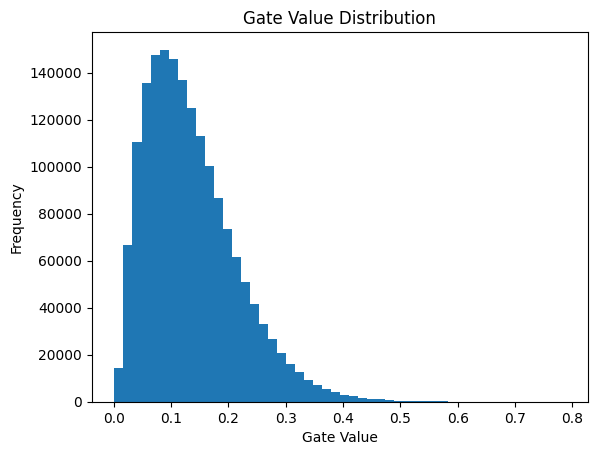

In [11]:
def plot_gates(model):
    gates_all = []

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores).detach().cpu().numpy().flatten()
            gates_all.extend(gates)

    plt.hist(gates_all, bins=50)
    plt.title("Gate Value Distribution")
    plt.xlabel("Gate Value")
    plt.ylabel("Frequency")
    plt.show()

plot_gates(model)